# Clasificación Multinomial Connect-4: One-vs-All

Este laboratorio implementa un modelo de regresión logística multiclase para predecir el resultado de una partida de Connect-4 (`win`, `loss`, `draw`) basándose en el estado del tablero (42 casillas). Se aplica un enfoque One-vs-All utilizando optimización avanzada y balanceo manual de datos.

## 1. Carga y Preprocesamiento de Datos

Cargamos el dataset utilizando `pandas`. Dado que las variables son categóricas ('x', 'o', 'b'), las transformamos a valores numéricos para que el modelo pueda procesarlas. También realizamos un **balanceo de clases** tomando una muestra equitativa de cada categoría para evitar sesgos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

%matplotlib inline

ruta = '../Datasets/3_connect+4/connect-4.data'
df = pd.read_csv(ruta, header=None)

# Mapeo numérico: x=1, o=-1, b=0
mapeo_piezas = {'x': 1, 'o': -1, 'b': 0}
for col in range(42):
    df[col] = df[col].map(mapeo_piezas)

# Mapeo objetivo: win=0, loss=1, draw=2
mapeo_resultado = {'win': 0, 'loss': 1, 'draw': 2}
df[42] = df[42].map(mapeo_resultado)

# Balanceo: Muestreamos según la clase minoritaria (draw)
conteo_clases = df[42].value_counts()
n_muestras = conteo_clases.min()

df_balanceado = pd.concat([
    df[df[42] == 0].sample(n_muestras, random_state=42),
    df[df[42] == 1].sample(n_muestras, random_state=42),
    df[df[42] == 2].sample(n_muestras, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribución de clases balanceada:")
print(df_balanceado[42].value_counts())
display(df_balanceado.head())

Distribución de clases balanceada:
42
2    6449
0    6449
1    6449
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,-1,0,0,0,0,0,0,0,0,0,...,-1,1,0,0,0,0,0,0,0,2
1,1,-1,0,0,0,0,0,0,0,0,...,0,0,0,-1,0,0,0,0,0,0
2,1,1,-1,0,0,0,1,-1,0,0,...,0,0,0,-1,1,0,0,0,0,2
3,1,0,0,0,0,0,1,1,-1,0,...,0,0,0,0,0,0,0,0,0,1
4,-1,0,0,0,0,0,1,1,-1,-1,...,0,0,0,0,0,0,0,0,0,1


## 2. División del Dataset (80/20)

Separamos el dataset en características (X) y etiquetas (y), destinando el 80% para el entrenamiento de los parámetros $\theta$ y el 20% para la validación final.

In [3]:
X = df_balanceado.drop(42, axis=1).values
y = df_balanceado[42].values

m = len(y)
indices = np.random.permutation(m)
limite = int(0.8 * m)

X_train, X_test = X[indices[:limite]], X[indices[limite:]]
y_train, y_test = y[indices[:limite]], y[indices[limite:]]

print(f"Entrenamiento: {X_train.shape[0]} ejemplos")
print(f"Prueba: {X_test.shape[0]} ejemplos")

Entrenamiento: 15477 ejemplos
Prueba: 3870 ejemplos


## 3. Implementación de Regresión Logística

Definimos la función sigmoide, la función de costo regularizada y el algoritmo One-vs-All. Utilizamos `scipy.optimize.minimize` para encontrar los valores óptimos de $\theta$ de manera eficiente.

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    if y.dtype == bool: y = y.astype(float)
    
    h = sigmoid(X.dot(theta))
    temp = theta.copy()
    temp[0] = 0
    
    epsilon = 1e-15
    J = (1 / m) * np.sum(-y * np.log(h + epsilon) - (1 - y) * np.log(1 - h + epsilon)) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp
    
    return J, grad

def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    historial_costos = []
    
    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        costos_clase = []
        
        def callback(t):
            costo_iter, _ = lrCostFunction(t, X, (y == c), lambda_)
            costos_clase.append(costo_iter)
            
        res = optimize.minimize(lrCostFunction, initial_theta, (X, (y == c), lambda_), 
                                jac=True, method='CG', callback=callback, options={'maxiter': 150})
        
        all_theta[c] = res.x
        historial_costos.append(costos_clase)
        print(f"Clasificador para clase {c} entrenado.")
        
    return all_theta, historial_costos

def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    return np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

## 4. Entrenamiento y Gráficas de Costo

Ejecutamos el entrenamiento y visualizamos cómo disminuye el costo $J$ para cada uno de los 3 clasificadores.

Clasificador para clase 0 entrenado.
Clasificador para clase 1 entrenado.
Clasificador para clase 2 entrenado.


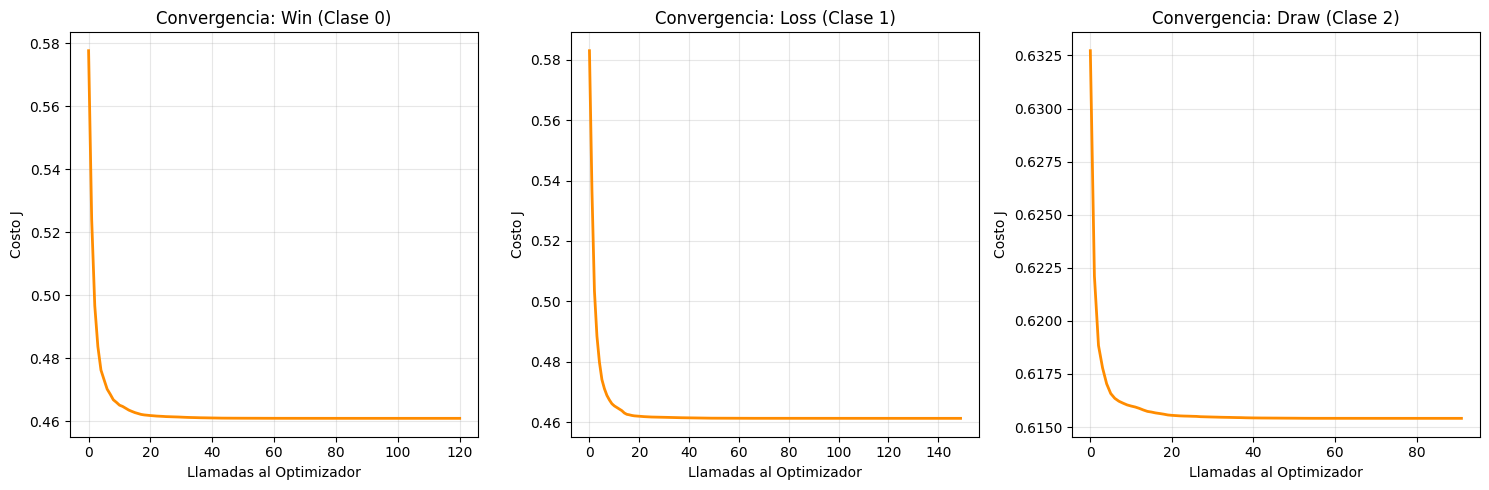

In [5]:
num_labels = 3
lambda_ = 0.1

all_theta, historiales = oneVsAll(X_train, y_train, num_labels, lambda_)

plt.figure(figsize=(15, 5))
titulos = ['Win (Clase 0)', 'Loss (Clase 1)', 'Draw (Clase 2)']
for i, hist in enumerate(historiales):
    plt.subplot(1, 3, i + 1)
    plt.plot(hist, color='darkorange', linewidth=2)
    plt.title(f'Convergencia: {titulos[i]}')
    plt.xlabel('Llamadas al Optimizador')
    plt.ylabel('Costo J')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Evaluación de Precisión

Comparamos los resultados obtenidos en el conjunto de entrenamiento contra el conjunto de prueba para verificar la capacidad de generalización del modelo.


Precisión en Entrenamiento: 60.74%
Precisión en Prueba: 58.81%


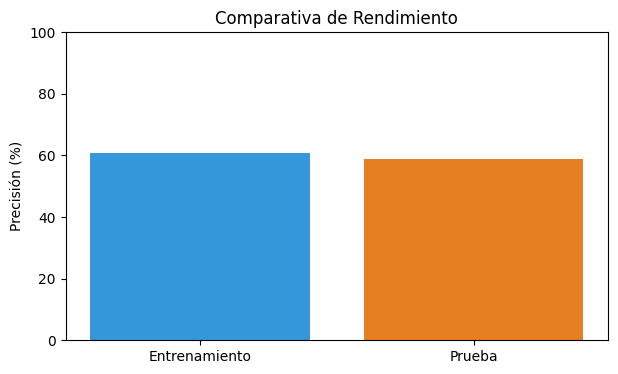

In [6]:
pred_train = predictOneVsAll(all_theta, X_train)
pred_test = predictOneVsAll(all_theta, X_test)

acc_train = np.mean(pred_train == y_train) * 100
acc_test = np.mean(pred_test == y_test) * 100

print(f"\nPrecisión en Entrenamiento: {acc_train:.2f}%")
print(f"Precisión en Prueba: {acc_test:.2f}%")

plt.figure(figsize=(7, 4))
plt.bar(['Entrenamiento', 'Prueba'], [acc_train, acc_test], color=['#3498DB', '#E67E22'])
plt.ylabel('Precisión (%)')
plt.title('Comparativa de Rendimiento')
plt.ylim(0, 100)
plt.show()

## 6. Muestra Aleatoria de Predicciones

Para finalizar, seleccionamos 30 ejemplos aleatorios del conjunto de prueba y comparamos la etiqueta real con la predicción del modelo.

In [7]:
indices_random = np.random.choice(len(y_test), 30, replace=False)
map_inv = {0: 'Win', 1: 'Loss', 2: 'Draw'}

df_res = pd.DataFrame({
    'Valor Real': [map_inv[val] for val in y_test[indices_random]],
    'Predicción': [map_inv[val] for val in pred_test[indices_random]]
})

df_res['¿Acertó?'] = np.where(df_res['Valor Real'] == df_res['Predicción'], '✅ Sí', '❌ No')

print("Visualización de 30 datos aleatorios de prueba:")
display(df_res)

Visualización de 30 datos aleatorios de prueba:


,Valor Real,Predicción,¿Acertó?
0,Draw,Win,❌ No
1,Loss,Loss,✅ Sí
2,Win,Loss,❌ No
3,Loss,Loss,✅ Sí
4,Draw,Loss,❌ No
5,Draw,Win,❌ No
6,Draw,Win,❌ No
7,Win,Win,✅ Sí
8,Win,Win,✅ Sí
9,Win,Win,✅ Sí
